<a href="https://colab.research.google.com/github/aygunhsynva/churn-data-analysis/blob/main/churn_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/aygunhsynva/churn-data-analysis/refs/heads/main/churn-data.csv")

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [ ]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.groupby("Geography")["CustomerId"].count()

,CustomerId
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
df.groupby(["Geography", "Gender"])["CustomerId"].count()

Geography  Gender
France     Female    2261
           Male      2753
Germany    Female    1193
           Male      1316
Spain      Female    1089
           Male      1388
Name: CustomerId, dtype: int64

In [ ]:
df.groupby(["Geography", "Gender"])["Exited"].sum()

Geography  Gender
France     Female    460
           Male      350
Germany    Female    448
           Male      366
Spain      Female    231
           Male      182
Name: Exited, dtype: int64

In [ ]:
df[df["Exited"] == 0].groupby(["Geography", "Gender"])["CustomerId"].count()

Geography  Gender
France     Female    1801
           Male      2403
Germany    Female     745
           Male       950
Spain      Female     858
           Male      1206
Name: CustomerId, dtype: int64

**Relation between HasCrCard and Exited**

In [ ]:
df[df['HasCrCard'] == 0]['RowNumber'].count()

np.int64(2945)

In [ ]:
df[df['HasCrCard'] == 1]['RowNumber'].count()

np.int64(7055)

In [ ]:
df[(df["HasCrCard"] == 0) & (df["Exited"] == 0)]["CustomerId"].count()

np.int64(2332)

In [ ]:
df[(df['HasCrCard'] == 0) & (df['Exited'] == 1)]["CustomerId"].count()

np.int64(613)

In [ ]:
df[(df["HasCrCard"] == 1) & (df["Exited"] == 0)]["CustomerId"].count()

np.int64(5631)

In [ ]:
df[(df["HasCrCard"] == 1) & (df["Exited"] == 1)]["CustomerId"].count()

np.int64(1424)

**Relation between IsActiveMember and Exited**

In [ ]:
df[df['IsActiveMember'] == 0]['RowNumber'].count()

np.int64(4849)

In [ ]:
df[df['IsActiveMember'] == 1]['RowNumber'].count()

np.int64(5151)

In [ ]:
df[(df['IsActiveMember'] == 0) & (df['Exited'] == 0)]["CustomerId"].count()

np.int64(3547)

In [ ]:
df[(df['IsActiveMember'] == 0) & (df['Exited'] == 1)]["CustomerId"].count()

np.int64(1302)

In [ ]:
df[(df['IsActiveMember'] == 1) & (df['Exited'] == 0)]["CustomerId"].count()

np.int64(4416)

In [ ]:
df[(df['IsActiveMember'] == 1) & (df['Exited'] == 1)]["CustomerId"].count()

np.int64(735)

**Relation with Tenure**

In [ ]:
df['Tenure'].min()

0

In [ ]:
df['Tenure'].max()

10

In [ ]:
df['Tenure'].mean()

np.float64(5.0128)

In [ ]:
df[(df['Tenure'] == 0) & df['Exited'] == 1]['RowNumber'].count()

np.int64(95)

**Relation with balance and salary**

In [ ]:
df[(df['Balance'] == 0) & (df['Exited'] == 1)]['RowNumber'].count()

np.int64(500)

In [ ]:
df['Balance'].min()

0.0

In [ ]:
df['Balance'].max()

250898.09

In [ ]:
avg_balance = df['Balance'].mean()
avg_balance

np.float64(76485.889288)

In [ ]:
df['EstimatedSalary'].min()

11.58

In [ ]:
df['EstimatedSalary'].max()

199992.48

In [ ]:
avg_salary = df['EstimatedSalary'].mean()
avg_salary

np.float64(100090.239881)

In [ ]:
q1_balance = df['Balance'].quantile(0.25)
q1_balance

np.float64(0.0)

In [ ]:
q3_balance = df['Balance'].quantile(0.75)
q3_balance

np.float64(127644.24)

In [ ]:
q1_salary = df['EstimatedSalary'].quantile(0.25)
q1_salary

np.float64(51002.11)

In [ ]:
q3_salary = df['EstimatedSalary'].quantile(0.75)
q3_salary

np.float64(149388.2475)

In [ ]:
df[df['Balance'] >= avg_balance]['Exited'].count()

np.int64(5919)

In [ ]:
df[df['Balance'] >= avg_balance]['Exited'].sum()

np.int64(1426)

In [ ]:
df[df['EstimatedSalary'] >= avg_salary]['Exited'].count()

np.int64(5007)

In [ ]:
df[df['EstimatedSalary'] >= avg_salary]['Exited'].sum()

np.int64(1042)

In [ ]:
df[(df['EstimatedSalary'] >= avg_salary) & (df['Balance'] >= avg_balance)]['Exited'].count()

np.int64(2996)

In [ ]:
df[(df['EstimatedSalary'] >= avg_salary) & (df['Balance'] >= avg_balance)]['Exited'].sum()

np.int64(733)

**Number of products**

In [ ]:
df['NumOfProducts'].unique()

array([1, 3, 2, 4])

In [ ]:
df.groupby('NumOfProducts')['RowNumber'].count()

,RowNumber
NumOfProducts,
1,5084
2,4590
3,266
4,60


In [ ]:
df[df['Exited'] == 1].groupby('NumOfProducts')['RowNumber'].count()

,RowNumber
NumOfProducts,
1,1409
2,348
3,220
4,60


In [ ]:
df[df['Exited'] == 0].groupby('NumOfProducts')['RowNumber'].count()

,RowNumber
NumOfProducts,
1,3675
2,4242
3,46


**Age**

In [ ]:
df['Age'].min()

18

In [ ]:
df['Age'].max()

92

In [ ]:
q3_age = df['Age'].quantile(0.75)
q3_age

np.float64(44.0)

In [ ]:
avg_age = df['Age'].mean()
avg_age

np.float64(38.9218)

In [ ]:
df[df['Age'] >= avg_age]['Exited'].count()

np.int64(4436)

In [ ]:
df[df['Age'] >= avg_age]['Exited'].sum()

np.int64(1512)

In [ ]:
df[df['Age'] >= q3_age]['Exited'].sum()

np.int64(1117)

**Visualization**

Text(0.5, 1.0, 'Exited vs Balance')

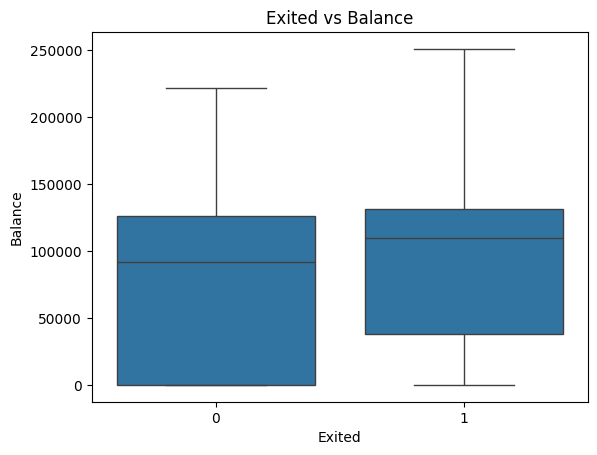

In [ ]:
sns.boxplot(data=df, x='Exited', y='Balance')
plt.title("Exited vs Balance")

Text(0.5, 1.0, 'Exited vs EstimatedSalary')

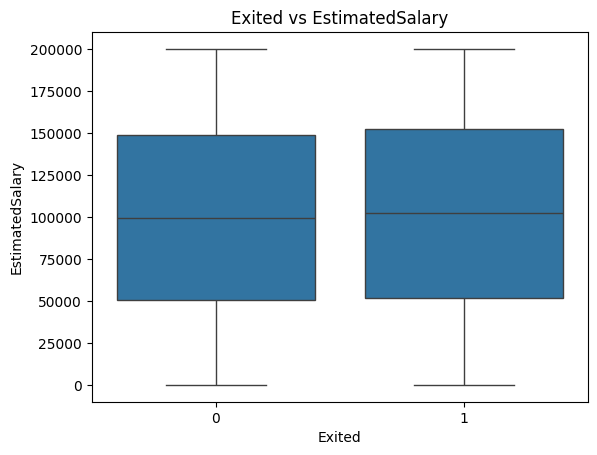

In [ ]:
sns.boxplot(data=df, x='Exited', y='EstimatedSalary')
plt.title("Exited vs EstimatedSalary")

<Axes: >

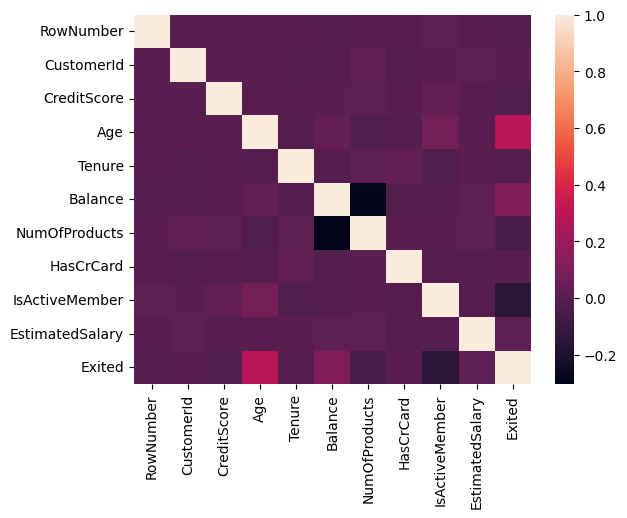

In [ ]:
sns.heatmap(data=df.corr(numeric_only=True))

Text(0.5, 1.0, 'Geography vs Exited')

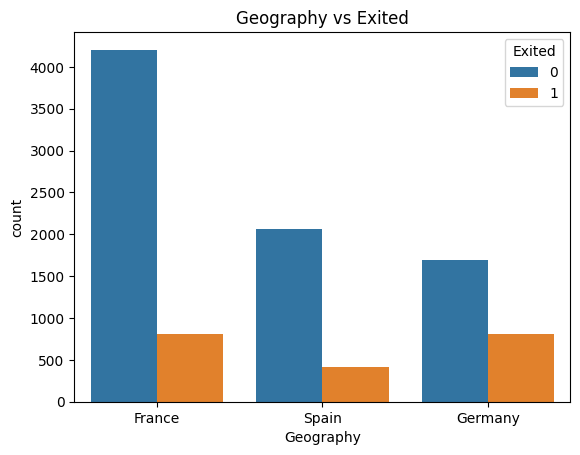

In [ ]:
sns.countplot(data=df, x="Geography", hue="Exited")
plt.title("Geography vs Exited")

Text(0.5, 1.0, 'Exited vs EstimatedSalary')

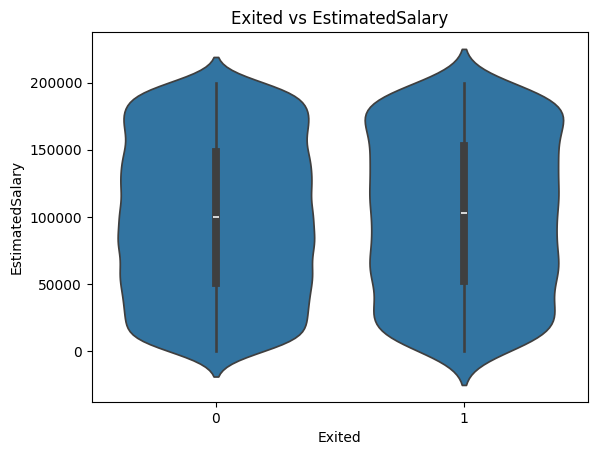

In [ ]:
sns.violinplot(data=df, x='Exited', y='EstimatedSalary')
plt.title("Exited vs EstimatedSalary")

<Axes: xlabel='Age', ylabel='Balance'>

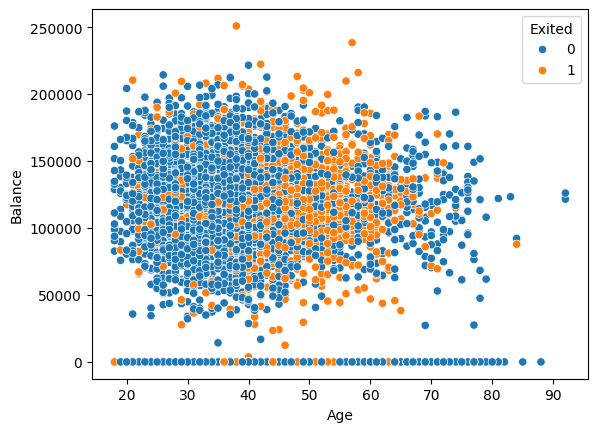

In [ ]:
sns.scatterplot(data=df, x="Age", y="Balance", hue="Exited")

<Axes: xlabel='NumOfProducts', ylabel='Balance'>

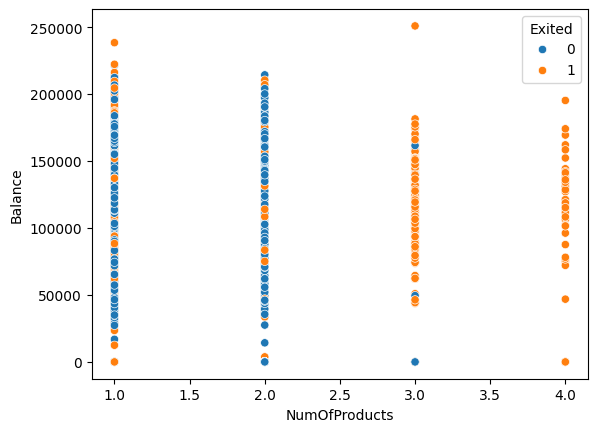

In [ ]:
sns.scatterplot(data=df, x="NumOfProducts", y="Balance", hue="Exited")

In [ ]:
df.groupby(["NumOfProducts", "HasCrCard", "Exited"])["CustomerId"].count()

NumOfProducts  HasCrCard  Exited
1              0          0         1088
                          1          418
               1          0         2587
                          1          991
2              0          0         1232
                          1          112
               1          0         3010
                          1          236
3              0          0           12
                          1           64
               1          0           34
                          1          156
4              0          1           19
               1          1           41
Name: CustomerId, dtype: int64

In [ ]:
df["CreditScore"].min()

350

In [ ]:
df2 = df.copy()
df2

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
credit_bins = [350, 500, 600, 700, 750, 850]
credit_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df2['CreditScore_Category'] = pd.cut(df2['CreditScore'], bins=credit_bins, labels=credit_labels, include_lowest=True)
df2

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScore_Category
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Medium
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Medium
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Low
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Medium
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,Very High
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,Low
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,High
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,Very High


In [ ]:
df2['Balance'].max()

250898.09

In [ ]:
balance_bins = [0, 50000, 100000, 150000, 200000, df2['Balance'].max()]
balance_labels = ['Very low', 'Low', 'Medium', 'High', 'Very high']
df2["Balance_Category"] = pd.cut(df2['Balance'], bins=balance_bins, labels=balance_labels, include_lowest=True)
df2

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScore_Category,Balance_Category
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Medium,Very low
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Medium,Low
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Low,High
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Medium,Very low
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Very High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,Very High,Very low
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,Low,Low
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,High,Very low
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,Very High,Low


In [ ]:
df2['Tenure'].min()

0

In [ ]:
age_bins = [df2['Age'].min(), 30, 45, 60, df2['Age'].max()]
age_labels = ['Young', 'Adult', 'Middle-aged', 'Senior']

df2['Age_Category'] = pd.cut(df2['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

In [ ]:
tenure_bins = [df2['Tenure'].min(), 2, 5, df2['Tenure'].max()]
tenure_labels = ['Short', 'Medium', 'Long']

df2['Tenure_Category'] = pd.cut(df2['Tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

In [ ]:
df2

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScore_Category,Balance_Category,Age_Category,Tenure_Category,Salary_Category
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Medium,Very low,Adult,Short,High
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Medium,Low,Adult,Short,High
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Low,High,Adult,Long,High
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Medium,Very low,Adult,Short,Medium
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Very High,Medium,Adult,Short,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,Very High,Very low,Adult,Medium,Medium
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,Low,Low,Adult,Long,High
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,High,Very low,Adult,Long,Low
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,Very High,Low,Adult,Medium,Medium


In [ ]:
df2['EstimatedSalary'].max()

199992.48

In [ ]:
salary_bins = [df2['EstimatedSalary'].min(), 50000, 100000, 150000, df2['EstimatedSalary'].max()]
salary_labels = ['Low', 'Medium', 'High', 'Very high']
df2['Salary_Category'] = pd.cut(df2['EstimatedSalary'], bins=salary_bins, labels=salary_labels)
df2

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScore_Category,Balance_Category,Age_Category,Tenure_Category,Salary_Category
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Medium,Very low,Adult,Short,High
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Medium,Low,Adult,Short,High
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Low,High,Adult,Long,High
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Medium,Very low,Adult,Short,Medium
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Very High,Medium,Adult,Short,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,Very High,Very low,Adult,Medium,Medium
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,Low,Low,Adult,Long,High
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,High,Very low,Adult,Long,Low
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,Very High,Low,Adult,Medium,Medium


In [ ]:
df2.groupby(['CreditScore_Category', 'Exited'])['RowNumber'].count()

/tmp/ipython-input-2532591260.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(['CreditScore_Category', 'Exited'])['RowNumber'].count()


CreditScore_Category  Exited
Very Low              0          491
                      1          152
Low                   0         1910
                      1          513
Medium                0         3065
                      1          753
High                  0         1212
                      1          306
Very High             0         1285
                      1          313
Name: RowNumber, dtype: int64

In [ ]:
df2.groupby(['Balance_Category', 'Exited'])['RowNumber'].count()

/tmp/ipython-input-2331321377.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(['Balance_Category', 'Exited'])['RowNumber'].count()


Balance_Category  Exited
Very low          0         3166
                  1          526
Low               0         1209
                  1          300
Medium            0         2843
                  1          987
High              0          730
                  1          205
Very high         0           15
                  1           19
Name: RowNumber, dtype: int64

In [ ]:
df2.groupby(['Tenure_Category', 'Exited'])['RowNumber'].count()

/tmp/ipython-input-369964216.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(['Tenure_Category', 'Exited'])['RowNumber'].count()


Tenure_Category  Exited
Short            0         1968
                 1          528
Medium           0         2385
                 1          625
Long             0         3610
                 1          884
Name: RowNumber, dtype: int64

In [ ]:
df2.groupby(['Age_Category', 'Exited'])['RowNumber'].count()

/tmp/ipython-input-1222719047.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(['Age_Category', 'Exited'])['RowNumber'].count()


Age_Category  Exited
Young         0         1820
              1          148
Adult         0         4989
              1          932
Middle-aged   0          805
              1          842
Senior        0          349
              1          115
Name: RowNumber, dtype: int64

In [ ]:
df2.groupby(['Salary_Category', 'Exited'])['RowNumber'].count()

/tmp/ipython-input-783064556.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(['Salary_Category', 'Exited'])['RowNumber'].count()


Salary_Category  Exited
Low              0         1964
                 1          488
Medium           0         2033
                 1          504
High             0         2038
                 1          517
Very high        0         1928
                 1          527
Name: RowNumber, dtype: int64

In [ ]:
df2.groupby(['Salary_Category', 'HasCrCard', 'Exited'])['RowNumber'].count()

/tmp/ipython-input-396984684.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(['Salary_Category', 'HasCrCard', 'Exited'])['RowNumber'].count()


Salary_Category  HasCrCard  Exited
Low              0          0          571
                            1          136
                 1          0         1393
                            1          352
Medium           0          0          586
                            1          152
                 1          0         1447
                            1          352
High             0          0          611
                            1          153
                 1          0         1427
                            1          364
Very high        0          0          564
                            1          172
                 1          0         1364
                            1          355
Name: RowNumber, dtype: int64

In [ ]:
df2.groupby(['Tenure_Category', 'Age_Category', 'Exited', 'IsActiveMember'])['RowNumber'].count()

/tmp/ipython-input-3511230138.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(['Tenure_Category', 'Age_Category', 'Exited', 'IsActiveMember'])['RowNumber'].count()


Tenure_Category  Age_Category  Exited  IsActiveMember
Short            Young         0       0                  175
                                       1                  251
                               1       0                   19
                                       1                    9
                 Adult         0       0                  588
                                       1                  661
                               1       0                  146
                                       1                   98
                 Middle-aged   0       0                   54
                                       1                  146
                               1       0                  146
                                       1                   78
                 Senior        0       0                    3
                                       1                   90
                               1       0                   17
                                       1                   15
Medium           Young         0       0                  277
                                       1                  284
                               1       0                   41
                                       1                   17
                 Adult         0       0                  726
                                       1                  769
                               1       0                  173
                                       1                   91
                 Middle-aged   0       0                   74
                                       1                  151
                               1       0                  157
                                       1                  107
                 Senior        0       0                    5
                                       1                   99
                               1       0                   27
                                       1                   12
Long             Young         0       0                  413
                                       1                  420
                               1       0                   37
                                       1                   25
                 Adult         0       0                 1103
                                       1                 1142
                               1       0                  275
                                       1                  149
                 Middle-aged   0       0                  121
                                       1                  259
                               1       0                  235
                                       1                  119
                 Senior        0       0                    8
                                       1                  144
                               1       0                   29
                                       1                   15
Name: RowNumber, dtype: int64

In [ ]:
df2.groupby(['Age_Category', 'IsActiveMember', 'Exited'])['RowNumber'].count()

/tmp/ipython-input-2012690460.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(['Age_Category', 'IsActiveMember', 'Exited'])['RowNumber'].count()


Age_Category  IsActiveMember  Exited
Young         0               0          865
                              1           97
              1               0          955
                              1           51
Adult         0               0         2417
                              1          594
              1               0         2572
                              1          338
Middle-aged   0               0          249
                              1          538
              1               0          556
                              1          304
Senior        0               0           16
                              1           73
              1               0          333
                              1           42
Name: RowNumber, dtype: int64

In [ ]:
categorical_columns = ['Age_Category', 'Tenure_Category', 'Balance_Category', 'CreditScore_Category', 'Salary_Category']

for col in categorical_columns:
    print(pd.crosstab(df2[col], df2['Exited'], normalize='index')*100)


Exited                0          1
Age_Category                      
Young         92.479675   7.520325
Adult         84.259416  15.740584
Middle-aged   48.876746  51.123254
Senior        75.215517  24.784483
Exited                   0          1
Tenure_Category                      
Short            78.846154  21.153846
Medium           79.235880  20.764120
Long             80.329328  19.670672
Exited                    0          1
Balance_Category                      
Very low          85.752979  14.247021
Low               80.119284  19.880716
Medium            74.229765  25.770235
High              78.074866  21.925134
Very high         44.117647  55.882353
Exited                        0          1
CreditScore_Category                      
Very Low              76.360809  23.639191
Low                   78.827899  21.172101
Medium                80.277632  19.722368
High                  79.841897  20.158103
Very High             80.413016  19.586984
Exited                   0

In [ ]:
pd.crosstab([df2['Age_Category'], df2['HasCrCard']], df2['Exited'], normalize='index') * 100

Exited                          0          1
Age_Category HasCrCard                      
Young        0          92.605634   7.394366
             1          92.428571   7.571429
Adult        0          84.699140  15.300860
             1          84.075670  15.924330
Middle-aged  0          45.766129  54.233871
             1          50.217202  49.782798
Senior       0          74.264706  25.735294
             1          75.609756  24.390244

In [ ]:
pd.crosstab([df2['Age_Category'], df2['IsActiveMember'], df2['HasCrCard'], df2['Gender']], df2['Exited'], normalize='index') * 100

Exited                                                0           1
Age_Category IsActiveMember HasCrCard Gender                       
Young        0              0         Female  87.096774   12.903226
                                      Male    92.465753    7.534247
                            1         Female  87.012987   12.987013
                                      Male    92.187500    7.812500
             1              0         Female  94.520548    5.479452
                                      Male    95.394737    4.605263
                            1         Female  92.384106    7.615894
                                      Male    96.798030    3.201970
Adult        0              0         Female  78.535354   21.464646
                                      Male    85.921325   14.078675
                            1         Female  74.845361   25.154639
                                      Male    83.046472   16.953528
             1              0         Female  84.552846   15.447154
                                      Male    88.531187   11.468813
                            1         Female  85.330347   14.669653
                                      Male    91.920070    8.079930
Middle-aged  0              0         Female  26.829268   73.170732
                                      Male    33.333333   66.666667
                            1         Female  28.178694   71.821306
                                      Male    36.940299   63.059701
             1              0         Female  48.854962   51.145038
                                      Male    69.343066   30.656934
                            1         Female  62.093863   37.906137
                                      Male    71.428571   28.571429
Senior       0              0         Female   0.000000  100.000000
                                      Male    30.769231   69.230769
                            1         Female  16.666667   83.333333
                                      Male    20.689655   79.310345
             1              0         Female  80.392157   19.607843
                                      Male    91.803279    8.196721
                            1         Female  88.695652   11.304348
                                      Male    90.540541    9.459459

In [ ]:
df2[(df2['Age_Category'] == 'Senior') & (df2['Gender'] == 'Female') & (df2['HasCrCard'] == 0) & (df2['IsActiveMember'] == 0)]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScore_Category,Balance_Category,Age_Category,Tenure_Category,Salary_Category
416,417,15720559,Heath,487,Germany,Female,61,5,110368.03,1,0,0,11384.45,1,Very Low,Medium,Senior,Medium,Low
1114,1115,15626147,Maclean,608,France,Female,62,8,144976.50,1,0,0,175836.03,1,Medium,Medium,Senior,Long,Very high
1410,1411,15710164,P'eng,523,France,Female,73,7,0.00,2,0,0,130883.90,1,Low,Very low,Senior,Long,High
3497,3498,15588944,Maughan,456,France,Female,63,1,165350.61,2,0,0,140758.07,1,Very Low,High,Senior,Short,High
3531,3532,15653251,Hickey,408,France,Female,84,8,87873.39,1,0,0,188484.52,1,Very Low,Low,Senior,Long,Very high
4559,4560,15668248,Quinn,528,Germany,Female,62,7,133201.17,1,0,0,168507.68,1,Low,Medium,Senior,Long,Very high
4563,4564,15694376,Sullivan,705,Germany,Female,64,3,153469.26,3,0,0,146573.66,1,High,High,Senior,Medium,High
5368,5369,15745326,Carandini,538,France,Female,62,3,75051.49,1,0,0,17682.02,1,Low,Low,Senior,Medium,Low
7629,7630,15591107,Flemming,723,Germany,Female,68,3,110357.00,1,0,0,141977.54,1,High,Medium,Senior,Medium,High
8098,8099,15594391,Samaniego,770,France,Female,68,2,183555.24,1,0,0,159557.28,1,Very High,High,Senior,Short,Very high


In [ ]:
pd.crosstab([df2['CreditScore_Category'], df2['IsActiveMember'], df2['HasCrCard']], df2['Exited'], normalize='index') * 100

Exited                                                 0          1
CreditScore_Category IsActiveMember HasCrCard                      
Very Low             0              0          71.276596  28.723404
                                    1          70.564516  29.435484
                     1              0          85.365854  14.634146
                                    1          81.735160  18.264840
Low                  0              0          73.900293  26.099707
                                    1          72.215844  27.784156
                     1              0          80.670103  19.329897
                                    1          86.998785  13.001215
Medium               0              0          75.797373  24.202627
                                    1          73.031956  26.968044
                     1              0          85.229202  14.770798
                                    1          86.482661  13.517339
High                 0              0          70.370370  29.629630
                                    1          74.245473  25.754527
                     1              0          83.043478  16.956522
                                    1          86.956522  13.043478
Very High            0              0          76.497696  23.502304
                                    1          72.131148  27.868852
                     1              0          84.313725  15.686275
                                    1          88.041594  11.958406

In [ ]:
pd.crosstab([df2['CreditScore_Category'], df2['IsActiveMember'], df2['HasCrCard'], df2['Gender']], df2['Exited'], normalize='index') * 100

Exited                                                        0          1
CreditScore_Category IsActiveMember HasCrCard Gender                      
Very Low             0              0         Female  63.043478  36.956522
                                              Male    79.166667  20.833333
                                    1         Female  69.421488  30.578512
                                              Male    71.653543  28.346457
                     1              0         Female  84.615385  15.384615
                                              Male    86.046512  13.953488
                                    1         Female  73.404255  26.595745
                                              Male    88.000000  12.000000
Low                  0              0         Female  69.565217  30.434783
                                              Male    76.847291  23.152709
                                    1         Female  67.088608  32.911392
                                              Male    76.470588  23.529412
                     1              0         Female  75.675676  24.324324
                                              Male    85.221675  14.778325
                                    1         Female  84.615385  15.384615
                                              Male    88.888889  11.111111
Medium               0              0         Female  69.685039  30.314961
                                              Male    81.362007  18.637993
                                    1         Female  68.046358  31.953642
                                              Male    77.466863  22.533137
                     1              0         Female  82.101167  17.898833
                                              Male    87.650602  12.349398
                                    1         Female  82.091918  17.908082
                                              Male    90.025575   9.974425
High                 0              0         Female  64.814815  35.185185
                                              Male    75.925926  24.074074
                                    1         Female  66.968326  33.031674
                                              Male    80.072464  19.927536
                     1              0         Female  78.846154  21.153846
                                              Male    86.507937  13.492063
                                    1         Female  84.426230  15.573770
                                              Male    88.821752  11.178248
Very High            0              0         Female  74.074074  25.925926
                                              Male    78.899083  21.100917
                                    1         Female  65.909091  34.090909
                                              Male    77.894737  22.105263
                     1              0         Female  79.464286  20.535714
                                              Male    88.111888  11.888112
                                    1         Female  84.251969  15.748031
                                              Male    91.021672   8.978328

In [ ]:
pd.crosstab([df2['NumOfProducts'], df2['IsActiveMember'], df2['HasCrCard']], df2['Exited'], normalize='index') * 100

Exited                                          0           1
NumOfProducts IsActiveMember HasCrCard                       
1             0              0          65.459610   34.540390
                             1          62.506933   37.493067
              1              0          78.426396   21.573604
                             1          82.253521   17.746479
2             0              0          89.573460   10.426540
                             1          90.337525    9.662475
              1              0          93.530239    6.469761
                             1          94.812680    5.187320
3             0              0           9.756098   90.243902
                             1          12.500000   87.500000
              1              0          22.857143   77.142857
                             1          25.641026   74.358974
4             0              0           0.000000  100.000000
                             1           0.000000  100.000000
              1              0           0.000000  100.000000
                             1           0.000000  100.000000

In [ ]:
pd.crosstab([df2['NumOfProducts'], df2['IsActiveMember'], df2['HasCrCard'], df2['Gender']], df2['Exited'], normalize='index') * 100

Exited                                                 0           1
NumOfProducts IsActiveMember HasCrCard Gender                       
1             0              0         Female  57.846154   42.153846
                                       Male    71.755725   28.244275
                             1         Female  56.698565   43.301435
                                       Male    67.528438   32.471562
              1              0         Female  75.139665   24.860335
                                       Male    81.162791   18.837209
                             1         Female  77.606178   22.393822
                                       Male    85.871743   14.128257
2             0              0         Female  87.375415   12.624585
                                       Male    91.566265    8.433735
                             1         Female  87.463557   12.536443
                                       Male    92.727273    7.272727
              1              0         Female  91.290323    8.709677
                                       Male    95.261845    4.738155
                             1         Female  92.267366    7.732634
                                       Male    96.810700    3.189300
3             0              0         Female   4.347826   95.652174
                                       Male    16.666667   83.333333
                             1         Female  11.764706   88.235294
                                       Male    13.636364   86.363636
              1              0         Female  13.043478   86.956522
                                       Male    41.666667   58.333333
                             1         Female  22.857143   77.142857
                                       Male    27.906977   72.093023
4             0              0         Female   0.000000  100.000000
                                       Male     0.000000  100.000000
                             1         Female   0.000000  100.000000
                                       Male     0.000000  100.000000
              1              0         Female   0.000000  100.000000
                                       Male     0.000000  100.000000
                             1         Female   0.000000  100.000000
                                       Male     0.000000  100.000000

In [ ]:
pd.crosstab([df2['Tenure_Category'], df2['HasCrCard']], df2['Exited'], normalize='index') * 100

Exited                             0          1
Tenure_Category HasCrCard                      
Short           0          79.467681  20.532319
                1          78.558875  21.441125
Medium          0          79.104478  20.895522
                1          79.289388  20.710612
Long            0          79.066148  20.933852
                1          80.835151  19.164849

In [ ]:
pd.crosstab([df2['Age_Category'], df2['IsActiveMember']], df2['Exited'], normalize='index') * 100

Exited                               0          1
Age_Category IsActiveMember                      
Young        0               89.916840  10.083160
             1               94.930417   5.069583
Adult        0               80.272335  19.727665
             1               88.384880  11.615120
Middle-aged  0               31.639136  68.360864
             1               64.651163  35.348837
Senior       0               17.977528  82.022472
             1               88.800000  11.200000

In [ ]:
pd.crosstab([df2['Tenure_Category'], df2['IsActiveMember']], df2['Exited'], normalize='index') * 100

Exited                                  0          1
Tenure_Category IsActiveMember                      
Short           0               71.428571  28.571429
                1               85.163205  14.836795
Medium          0               73.108108  26.891892
                1               85.163399  14.836601
Long            0               74.065736  25.934264
                1               86.449626  13.550374

In [ ]:
pd.crosstab([df2['Salary_Category'], df2['IsActiveMember']], df2['Exited'], normalize='index') * 100

Exited                                  0          1
Salary_Category IsActiveMember                      
Low             0               74.005080  25.994920
                1               85.759245  14.240755
Medium          0               73.142857  26.857143
                1               86.661585  13.338415
High            0               73.620130  26.379870
                1               85.487528  14.512472
Very high       0               71.841453  28.158547
                1               85.048232  14.951768

In [ ]:
pd.crosstab([df2['HasCrCard'], df2['IsActiveMember']], df2['Exited'], normalize='index') * 100

Exited                            0          1
HasCrCard IsActiveMember                      
0         0               74.304069  25.695931
          1               83.613990  16.386010
1         0               72.679814  27.320186
          1               86.637095  13.362905

In [ ]:
pd.crosstab([df2['NumOfProducts'], df2['IsActiveMember']], df2['Exited'], normalize='index') * 100

Exited                                0           1
NumOfProducts IsActiveMember                       
1             0               63.347878   36.652122
              1               81.076863   18.923137
2             0               90.111940    9.888060
              1               94.439902    5.560098
3             0               11.764706   88.235294
              1               24.778761   75.221239
4             0                0.000000  100.000000
              1                0.000000  100.000000

In [ ]:
pd.crosstab([df2['Tenure_Category'], df2['IsActiveMember'], df2['HasCrCard'], df2['Gender']], df2['Exited'], normalize='index') * 100

Exited                                                   0          1
Tenure_Category IsActiveMember HasCrCard Gender                      
Short           0              0         Female  65.517241  34.482759
                                         Male    79.545455  20.454545
                               1         Female  66.578947  33.421053
                                         Male    74.880383  25.119617
                1              0         Female  78.865979  21.134021
                                         Male    89.795918  10.204082
                               1         Female  83.091787  16.908213
                                         Male    87.070707  12.929293
Medium          0              0         Female  68.983957  31.016043
                                         Male    81.333333  18.666667
                               1         Female  66.863905  33.136095
                                         Male    76.827094  23.172906
                1              0         Female  79.411765  20.588235
                                         Male    84.313725  15.686275
                               1         Female  82.212581  17.787419
                                         Male    89.672131  10.327869
Long            0              0         Female  71.331058  28.668942
                                         Male    76.878613  23.121387
                               1         Female  68.245125  31.754875
                                         Male    78.703704  21.296296
                1              0         Female  80.267559  19.732441
                                         Male    86.743516  13.256484
                               1         Female  83.146067  16.853933
                                         Male    90.928962   9.071038

In [ ]:
pd.crosstab([df2['CreditScore_Category'], df2['IsActiveMember'], df2['HasCrCard'], df2['Gender']], df2['Exited'], normalize='index') * 100

Exited                                                        0          1
CreditScore_Category IsActiveMember HasCrCard Gender                      
Very Low             0              0         Female  63.043478  36.956522
                                              Male    79.166667  20.833333
                                    1         Female  69.421488  30.578512
                                              Male    71.653543  28.346457
                     1              0         Female  84.615385  15.384615
                                              Male    86.046512  13.953488
                                    1         Female  73.404255  26.595745
                                              Male    88.000000  12.000000
Low                  0              0         Female  69.565217  30.434783
                                              Male    76.847291  23.152709
                                    1         Female  67.088608  32.911392
                                              Male    76.470588  23.529412
                     1              0         Female  75.675676  24.324324
                                              Male    85.221675  14.778325
                                    1         Female  84.615385  15.384615
                                              Male    88.888889  11.111111
Medium               0              0         Female  69.685039  30.314961
                                              Male    81.362007  18.637993
                                    1         Female  68.046358  31.953642
                                              Male    77.466863  22.533137
                     1              0         Female  82.101167  17.898833
                                              Male    87.650602  12.349398
                                    1         Female  82.091918  17.908082
                                              Male    90.025575   9.974425
High                 0              0         Female  64.814815  35.185185
                                              Male    75.925926  24.074074
                                    1         Female  66.968326  33.031674
                                              Male    80.072464  19.927536
                     1              0         Female  78.846154  21.153846
                                              Male    86.507937  13.492063
                                    1         Female  84.426230  15.573770
                                              Male    88.821752  11.178248
Very High            0              0         Female  74.074074  25.925926
                                              Male    78.899083  21.100917
                                    1         Female  65.909091  34.090909
                                              Male    77.894737  22.105263
                     1              0         Female  79.464286  20.535714
                                              Male    88.111888  11.888112
                                    1         Female  84.251969  15.748031
                                              Male    91.021672   8.978328

In [ ]:
pd.crosstab([df2['Salary_Category'], df2['IsActiveMember'], df2['HasCrCard'], df2['Gender']], df2['Exited'], normalize='index') * 100

Exited                                                   0          1
Salary_Category IsActiveMember HasCrCard Gender                      
Low             0              0         Female  71.974522  28.025478
                                         Male    81.005587  18.994413
                               1         Female  66.579634  33.420366
                                         Male    78.138528  21.861472
                1              0         Female  81.818182  18.181818
                                         Male    86.407767  13.592233
                               1         Female  82.835821  17.164179
                                         Male    89.156627  10.843373
Medium          0              0         Female  69.325153  30.674847
                                         Male    77.294686  22.705314
                               1         Female  67.263427  32.736573
                                         Male    77.586207  22.413793
                1              0         Female  83.660131  16.339869
                                         Male    86.046512  13.953488
                               1         Female  83.456790  16.543210
                                         Male    90.166976   9.833024
High            0              0         Female  71.428571  28.571429
                                         Male    81.420765  18.579235
                               1         Female  68.253968  31.746032
                                         Male    76.510067  23.489933
                1              0         Female  77.227723  22.772277
                                         Male    87.614679  12.385321
                               1         Female  83.578431  16.421569
                                         Male    89.494949  10.505051
Very high       0              0         Female  64.161850  35.838150
                                         Male    75.842697  24.157303
                               1         Female  67.435897  32.564103
                                         Male    76.808511  23.191489
                1              0         Female  76.836158  23.163842
                                         Male    87.500000  12.500000
                               1         Female  81.451613  18.548387
                                         Male    89.733060  10.266940

In [ ]:
pd.crosstab([df2['Balance_Category'], df2['IsActiveMember'], df2['HasCrCard'], df2['Gender']], df2['Exited'], normalize='index') * 100

Exited                                                    0           1
Balance_Category IsActiveMember HasCrCard Gender                       
Very low         0              0         Female  76.271186   23.728814
                                          Male    88.257576   11.742424
                                1         Female  75.126904   24.873096
                                          Male    84.883721   15.116279
                 1              0         Female  84.081633   15.918367
                                          Male    90.540541    9.459459
                                1         Female  89.120000   10.880000
                                          Male    92.904953    7.095047
Low              0              0         Female  63.461538   36.538462
                                          Male    80.357143   19.642857
                                1         Female  68.979592   31.020408
                                          Male    77.865613   22.134387
                 1              0         Female  77.862595   22.137405
                                          Male    88.721805   11.278195
                                1         Female  84.862385   15.137615
                                          Male    90.095847    9.904153
Medium           0              0         Female  65.737052   34.262948
                                          Male    72.635135   27.364865
                                1         Female  59.935380   40.064620
                                          Male    69.971671   30.028329
                 1              0         Female  75.819672   24.180328
                                          Male    85.588235   14.411765
                                1         Female  77.049180   22.950820
                                          Male    85.340314   14.659686
High             0              0         Female  65.000000   35.000000
                                          Male    69.444444   30.555556
                                1         Female  66.438356   33.561644
                                          Male    75.935829   24.064171
                 1              0         Female  83.333333   16.666667
                                          Male    79.452055   20.547945
                                1         Female  78.461538   21.538462
                                          Male    93.333333    6.666667
Very high        0              0         Female  66.666667   33.333333
                                          Male    33.333333   66.666667
                                1         Female  25.000000   75.000000
                                          Male    77.777778   22.222222
                 1              0         Female  40.000000   60.000000
                                          Male    20.000000   80.000000
                                1         Female  25.000000   75.000000
                                          Male     0.000000  100.000000

In [ ]:
df2[(df2['Gender'] == 'Male') & (df2['Balance_Category'] == 'Very high') & (df2['IsActiveMember'] == 1) & (df2['HasCrCard'] == 1)]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScore_Category,Balance_Category,Age_Category,Tenure_Category,Salary_Category
6271,6272,15620756,Stokes,747,France,Male,49,6,202904.64,1,1,1,17298.72,1,High,Very high,Middle-aged,Long,Low


In [ ]:
df2[(df2['Gender'] == 'Female') & (df2['Balance_Category'] == 'Very high') & (df2['IsActiveMember'] == 1) & (df2['HasCrCard'] == 1)]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScore_Category,Balance_Category,Age_Category,Tenure_Category,Salary_Category
720,721,15721658,Fleming,672,Spain,Female,56,2,209767.31,2,1,1,150694.42,1,Medium,Very high,Middle-aged,Short,Very high
2597,2598,15668818,Chidubem,592,Spain,Female,40,2,200322.45,1,1,1,113244.73,0,Low,Very high,Adult,Short,High
6913,6914,15784180,Ku,564,France,Female,36,7,206329.65,1,1,1,46632.87,1,Low,Very high,Adult,Long,Low
8794,8795,15578671,Webb,706,Spain,Female,29,1,209490.21,1,1,1,133267.69,1,High,Very high,Young,Short,High
